In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
Folder=r"/content/drive/MyDrive/Colab Notebooks/EMI"


In [12]:
files=sorted(glob.glob(os.path.join(Folder,"ZNL_SpectrumMode_UserManual_*.CSV")))
print(f"{len(files)}")

73


In [13]:
skiprows=40
df_test=pd.read_csv(files[0],skiprows=skiprows,header=None)
print(df_test.head(10))

                       0                      1   2
0  1380072007.2007205486  -80.59200286865234375 NaN
1  1380080008.0008006096   -79.3577423095703125 NaN
2  1380088008.8008806705   -80.4098968505859375 NaN
3  1380096009.6009607315   -79.1574554443359375 NaN
4  1380104010.4010407925   -79.8820648193359375 NaN
5  1380112011.2011208534  -80.12120819091796875 NaN
6  1380120012.0012009144   -79.6596221923828125 NaN
7  1380128012.8012809753  -79.93604278564453125 NaN
8  1380136013.6013610363  -79.82651519775390625 NaN
9  1380144014.4014410973    -80.197601318359375 NaN


In [14]:
f_low=1.419e9
f_high=1.421e9
skiprows=40

def read_csv(path):
    df=pd.read_csv(path,skiprows=skiprows,header=None).iloc[:,:2]
    df.columns=["freq","power"]
    df=df.apply(pd.to_numeric,errors="coerce").dropna()
    return df

In [15]:
#find angels
def az_el(path):
    base=os.path.basename(path)
    m=re.search(r"_Az(?P<az>-?\d+)_Al(?P<al>-?\d+)\.CSV$",base,re.IGNORECASE)
    az=float(m.group("az"))
    el=float(m.group("al"))
    return az,el

In [16]:
rows=[]
for f in files:
    az,el=az_el(f)
    spec=read_csv(f)
    b=spec[(spec["freq"]>=f_low)&(spec["freq"]<=f_high)]
    mean=b["power"].mean()
    rows.append({"az":az,"el":el,"mean":mean})
df=pd.DataFrame(rows).sort_values(["az","el"]).reset_index(drop=True)
print(df)

       az    el       mean
0     0.0  30.0 -81.021400
1    30.0  15.0 -82.202599
2    30.0  30.0 -82.601986
3    30.0  45.0 -82.468451
4    30.0  60.0 -82.558853
..    ...   ...        ...
68  330.0  60.0 -82.368317
69  330.0  75.0 -82.143851
70  360.0  45.0 -82.383691
71  360.0  60.0 -82.498346
72  360.0  75.0 -82.126895

[73 rows x 3 columns]


In [17]:
rows=[]
for f in files:
    az,el=az_el(f)
    spec=read_csv(f)
    b=spec[(spec["freq"]>=f_low)&(spec["freq"]<=f_high)]
    mean=b["power"].mean()
    rms=b["power"].std(ddof=1)
    pmr=np.percentile(b["power"],99)-mean
    rows.append({"az":az,"el":el,"mean":mean,"rms":rms,"pmr":pmr})
df=pd.DataFrame(rows).sort_values(["az","el"]).reset_index(drop=True)

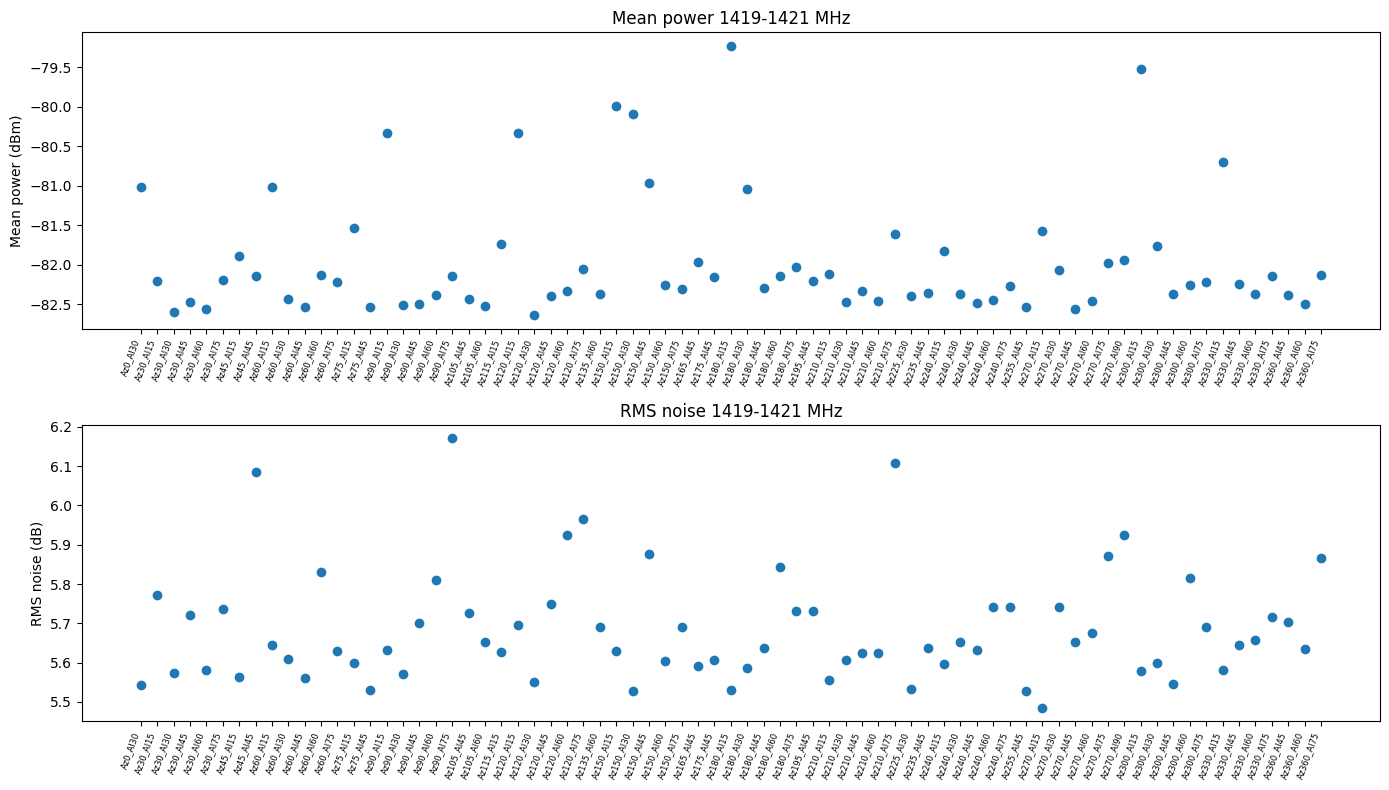

In [18]:
df["label"]=df.apply(lambda r: f"Az{int(r.az)}_Al{int(r.el)}",axis=1)

fig,axes=plt.subplots(2,1,figsize=(14,8))
axes[0].scatter(range(len(df)),df["mean"])
axes[0].set_xticks(range(len(df)))
axes[0].set_xticklabels(df["label"],rotation=70,ha="right",fontsize=6)
axes[0].set_ylabel("Mean power (dBm)")
axes[0].set_title(f"Mean power 1419-1421 MHz")

axes[1].scatter(range(len(df)),df["rms"])
axes[1].set_xticks(range(len(df)))
axes[1].set_xticklabels(df["label"],rotation=70,ha="right",fontsize=6)
axes[1].set_ylabel("RMS noise (dB)")
axes[1].set_title("RMS noise 1419-1421 MHz")

plt.tight_layout()
plt.show()

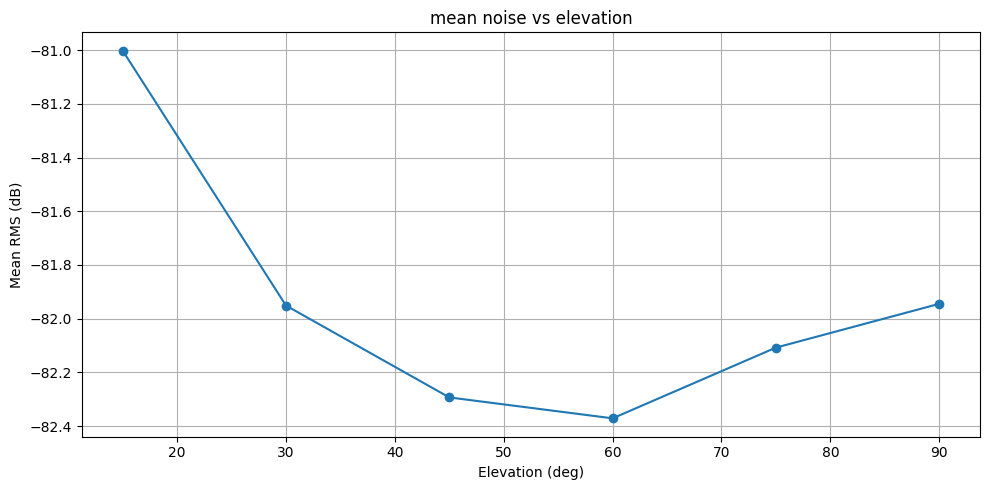

In [42]:
grid=df.pivot_table(index="el",columns="az",values="mean")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(grid.index,np.nanmean(grid.values,axis=1),marker="o")
ax.set_xlabel("Elevation (deg)")
ax.set_ylabel("Mean RMS (dB)")
ax.set_title("mean noise vs elevation")
ax.grid(True)
plt.tight_layout()
plt.show()

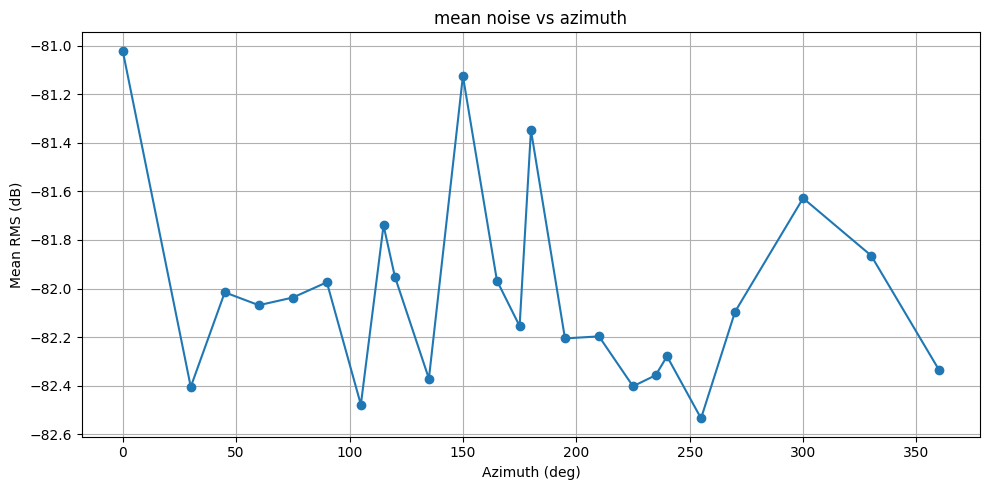

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(grid.columns, np.nanmean(grid.values, axis=0), marker="o")
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Mean RMS (dB)")
ax.set_title("mean noise vs azimuth")
ax.grid(True)
plt.tight_layout()
plt.show()


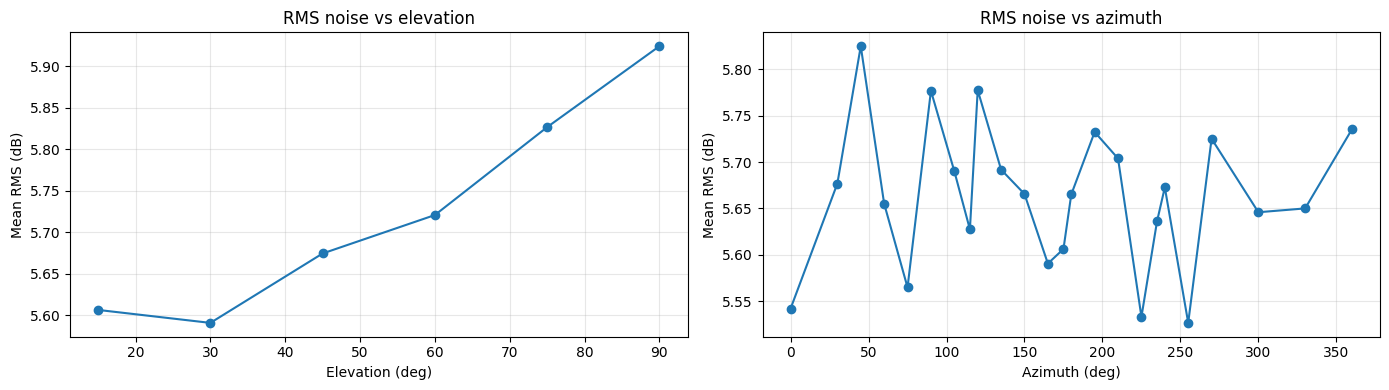

In [44]:
grid=df.pivot_table(index="el",columns="az",values="rms")

fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(grid.index,np.nanmean(grid.values,axis=1),marker="o")
axes[0].set_xlabel("Elevation (deg)")
axes[0].set_ylabel("Mean RMS (dB)")
axes[0].set_title("RMS noise vs elevation")
axes[0].grid(alpha=0.3)

axes[1].plot(grid.columns,np.nanmean(grid.values,axis=0),marker="o")
axes[1].set_xlabel("Azimuth (deg)")
axes[1].set_ylabel("Mean RMS (dB)")
axes[1].set_title("RMS noise vs azimuth")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

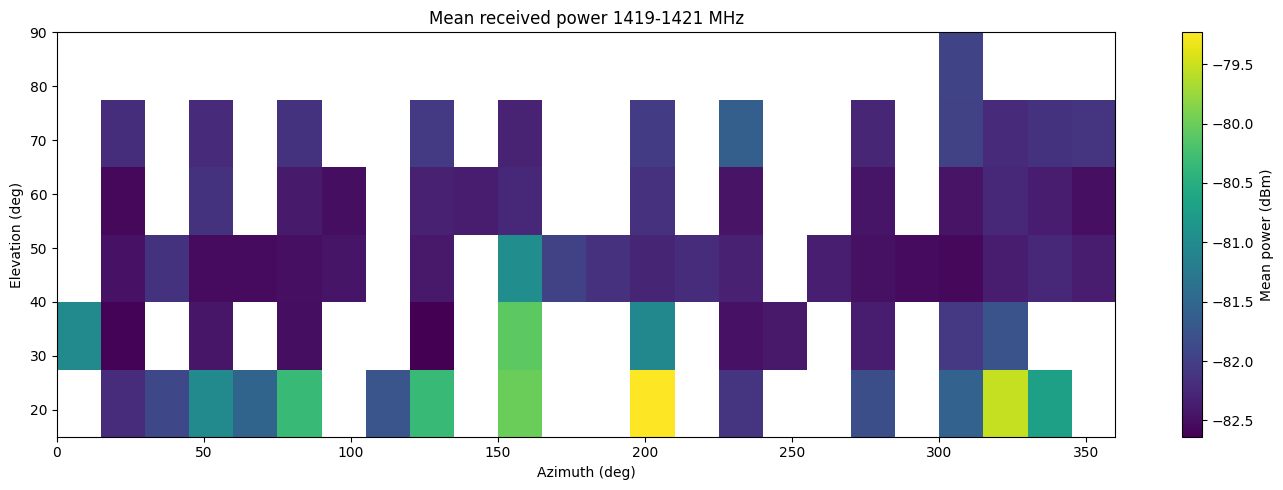

In [24]:
pivot=df.pivot_table(index="el",columns="az",values="mean")
plt.figure(figsize=(14,5))
plt.imshow(pivot.values,origin="lower",aspect="auto",
    extent=[pivot.columns.min(),pivot.columns.max(),pivot.index.min(),pivot.index.max()])
plt.colorbar(label="Mean power (dBm)")
plt.xlabel("Azimuth (deg)")
plt.ylabel("Elevation (deg)")
plt.title("Mean received power 1419-1421 MHz")
plt.tight_layout()
plt.show()

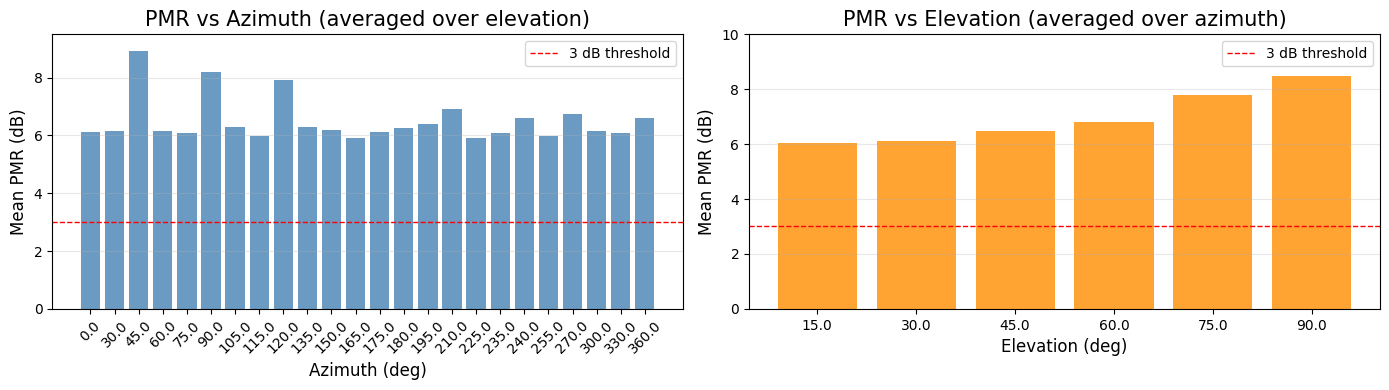

In [41]:
pivot_pmr=df.pivot_table(index="el",columns="az",values="pmr")

fig,axes=plt.subplots(1,2,figsize=(14,4))
pmr_az=df.groupby("az")["pmr"].mean()
axes[0].bar(pmr_az.index.astype(str),pmr_az.values,color='steelblue',alpha=0.8)
axes[0].axhline(y=3,color='red',ls='--',lw=1,label='3 dB threshold')
axes[0].set_xlabel("Azimuth (deg)",fontsize=12)
axes[0].set_ylabel("Mean PMR (dB)",fontsize=12)
axes[0].set_title("PMR vs Azimuth (averaged over elevation)",fontsize=15)
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_ylim(0,9.5)
axes[0].legend()
axes[0].grid(alpha=0.3,axis='y')

pmr_el=df.groupby("el")["pmr"].mean()
axes[1].bar(pmr_el.index.astype(str),pmr_el.values,color='darkorange',alpha=0.8)
axes[1].axhline(y=3,color='red',ls='--',lw=1,label='3 dB threshold')
axes[1].set_xlabel("Elevation (deg)",fontsize=12)
axes[1].set_ylabel("Mean PMR (dB)",fontsize=12)
axes[1].set_title("PMR vs Elevation (averaged over azimuth)",fontsize=15)
axes[1].legend()
axes[1].grid(alpha=0.3,axis='y')
axes[1].set_ylim(0,10)
plt.tight_layout()
plt.show()